
# Deep Learning Text Generation Project
## Vanilla RNN vs LSTM vs GRU

### Objective
Design and implement deep learning models capable of learning grammar, structure, and contextual dependencies from a text corpus and generating coherent text.

### Models
1. Vanilla RNN
2. LSTM
3. GRU

### Learning Outcomes
- Text preprocessing
- Tokenization
- Sequence generation
- Deep Learning for NLP
- Comparative analysis of RNN architectures


In [1]:

# Install (Google Colab)
!pip -q install tensorflow


In [2]:

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.utils import to_categorical

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


## Step 1: Load Text Corpus

In [3]:

corpus = '''
artificial intelligence is transforming the world
machine learning helps computers learn patterns
deep learning is a subset of machine learning
recurrent neural networks process sequential data
lstm networks learn long term dependencies
gru networks provide efficient sequence modeling
natural language processing enables text understanding
text generation creates meaningful sentences
data science combines statistics and computing
artificial intelligence powers modern applications
'''

corpus = corpus.lower()
print(corpus)



artificial intelligence is transforming the world
machine learning helps computers learn patterns
deep learning is a subset of machine learning
recurrent neural networks process sequential data
lstm networks learn long term dependencies
gru networks provide efficient sequence modeling
natural language processing enables text understanding
text generation creates meaningful sentences
data science combines statistics and computing
artificial intelligence powers modern applications



## Step 2: Text Preprocessing

In [4]:

tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

input_sequences = []

for line in corpus.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram = token_list[:i+1]
        input_sequences.append(n_gram)

max_seq_len = max(len(x) for x in input_sequences)

input_sequences = np.array(
    pad_sequences(input_sequences,
                  maxlen=max_seq_len,
                  padding='pre')
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = to_categorical(y, num_classes=total_words)

print("Vocabulary Size:", total_words)
print("Input Shape:", X.shape)
print("Output Shape:", y.shape)


Vocabulary Size: 50
Input Shape: (50, 7)
Output Shape: (50, 50)


## Step 3: Build Models

In [5]:

def build_rnn():
    model = Sequential([
        Embedding(total_words, 64, input_length=max_seq_len-1),
        SimpleRNN(128),
        Dropout(0.2),
        Dense(total_words, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

def build_lstm():
    model = Sequential([
        Embedding(total_words, 64, input_length=max_seq_len-1),
        LSTM(128),
        Dropout(0.2),
        Dense(total_words, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

def build_gru():
    model = Sequential([
        Embedding(total_words, 64, input_length=max_seq_len-1),
        GRU(128),
        Dropout(0.2),
        Dense(total_words, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model


## Step 4: Train Models

In [6]:

EPOCHS = 25

rnn_model = build_rnn()
lstm_model = build_lstm()
gru_model = build_gru()

rnn_hist = rnn_model.fit(X,y,epochs=EPOCHS,verbose=0)
lstm_hist = lstm_model.fit(X,y,epochs=EPOCHS,verbose=0)
gru_hist = gru_model.fit(X,y,epochs=EPOCHS,verbose=0)

print("Training Finished")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training Finished


## Step 5: Performance Comparison

In [7]:

comparison = pd.DataFrame({
    'Model':['RNN','LSTM','GRU'],
    'Final Accuracy':[
        rnn_hist.history['accuracy'][-1],
        lstm_hist.history['accuracy'][-1],
        gru_hist.history['accuracy'][-1]
    ],
    'Final Loss':[
        rnn_hist.history['loss'][-1],
        lstm_hist.history['loss'][-1],
        gru_hist.history['loss'][-1]
    ]
})

comparison.sort_values('Final Accuracy',ascending=False)


,Model,Final Accuracy,Final Loss
0,RNN,0.72,2.189191
2,GRU,0.16,3.330272
1,LSTM,0.12,3.343724


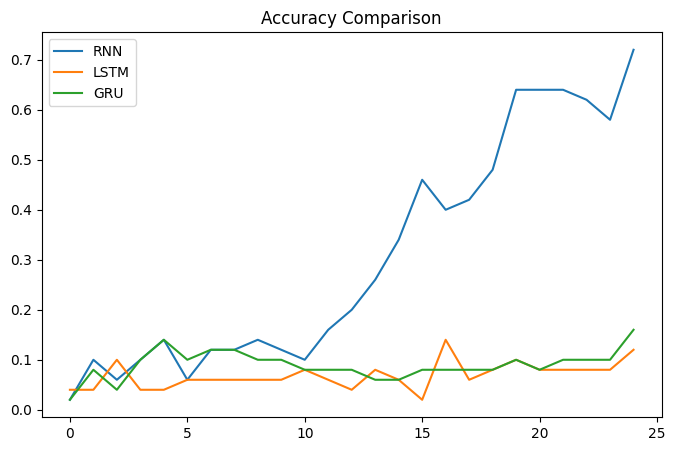

In [8]:

plt.figure(figsize=(8,5))
plt.plot(rnn_hist.history['accuracy'],label='RNN')
plt.plot(lstm_hist.history['accuracy'],label='LSTM')
plt.plot(gru_hist.history['accuracy'],label='GRU')
plt.title("Accuracy Comparison")
plt.legend()
plt.show()


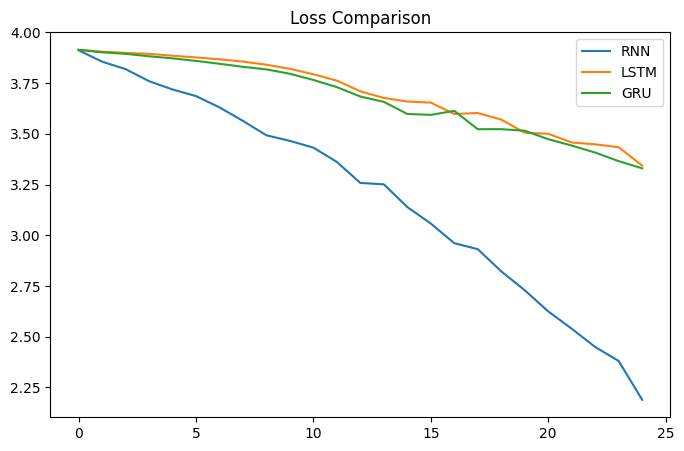

In [9]:

plt.figure(figsize=(8,5))
plt.plot(rnn_hist.history['loss'],label='RNN')
plt.plot(lstm_hist.history['loss'],label='LSTM')
plt.plot(gru_hist.history['loss'],label='GRU')
plt.title("Loss Comparison")
plt.legend()
plt.show()


## Step 6: Text Generation

In [10]:

def generate_text(model, seed_text, next_words=8):

    for _ in range(next_words):

        seq = tokenizer.texts_to_sequences([seed_text])[0]

        seq = pad_sequences(
            [seq],
            maxlen=max_seq_len-1,
            padding='pre'
        )

        pred = np.argmax(model.predict(seq, verbose=0))

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == pred:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text


In [11]:

seed = "artificial intelligence"

print("RNN Output:")
print(generate_text(rnn_model, seed))

print("\nLSTM Output:")
print(generate_text(lstm_model, seed))

print("\nGRU Output:")
print(generate_text(gru_model, seed))


RNN Output:
artificial intelligence is modern the world creates machine learning sequential

LSTM Output:
artificial intelligence networks networks networks learn dependencies dependencies dependencies dependencies

GRU Output:
artificial intelligence intelligence intelligence intelligence intelligence intelligence is intelligence intelligence



# Analysis

| Model | Strength |
|---------|-----------|
| Vanilla RNN | Simple architecture, fast training |
| LSTM | Handles long-term dependencies effectively |
| GRU | Faster than LSTM with comparable performance |

# Conclusion

- Implemented three recurrent architectures.
- Compared training accuracy and loss.
- Generated new text sequences.
- Observed that LSTM and GRU generally outperform Vanilla RNN in contextual learning.
- Suitable for NLP tasks such as text generation, language modeling, and sequence prediction.


